In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import BatchNormalization, Conv2D, MaxPooling2D, Dense, Dropout, Flatten,Input
from sklearn.metrics import classification_report

In [4]:
train_df = pd.read.csv('C:/Users/Sandhya/Desktop/pr sem8/fashion-mnist_train.csv')
test_df = pd.read.csv('C:/Users/Sandhya/Desktop/pr sem8/fashion-mnist_test.csv')

In [5]:
class_names = ['T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat',
              'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ancle boot']

In [6]:
x_train = train_df.iloc[:, 1:].values.reshape(-1, 28, 28, 1) / 255.0
y_train = train_df.iloc[:, 0].values
x_test = test_df.iloc[:, 1:].values.reshape(-1, 28, 28, 1) / 255.0
y_test = test_df.iloc[:, 0].values

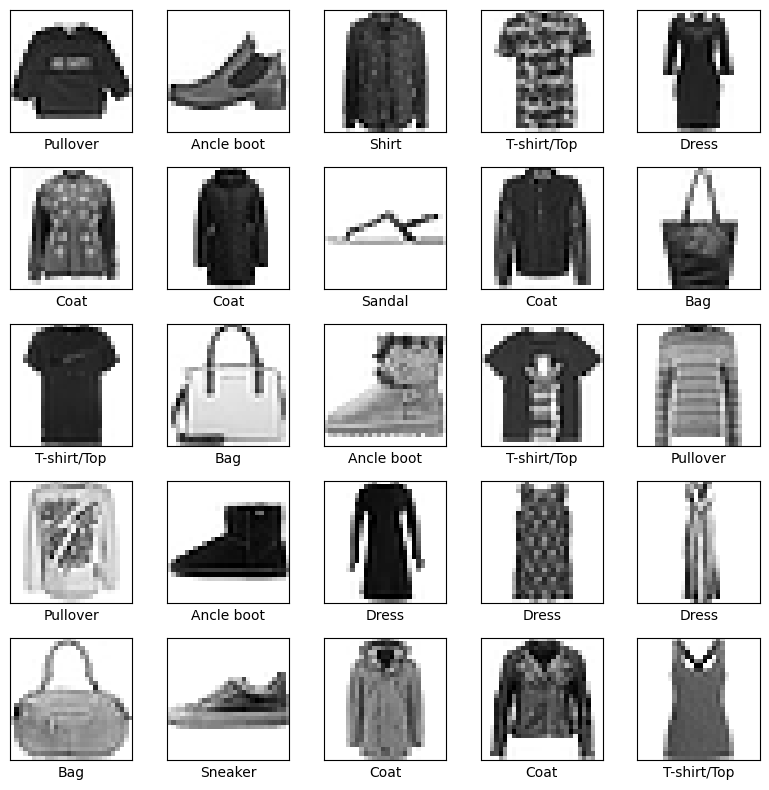

In [19]:
plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([]), plt.yticks([]), plt.grid(False)
    plt.imshow(x_train[i], cmap='binary')
    plt.xlabel(class_names[y_train[i]])
plt.tight_layout()
plt.show()

In [21]:
model = Sequential()

model.add(Input(shape=(28,28,1)))
model.add(Conv2D(32, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', 
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 26, 26, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 11, 11, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 225,418 (880.54 KB)

 Trainable params: 225,226 (879.79 KB)

 Non-trainable params: 192 (768.00 B)

In [23]:
model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.05)

Epoch 1/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.7772 - loss: 0.6256 - val_accuracy: 0.8617 - val_loss: 0.3846
Epoch 2/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.8464 - loss: 0.4241 - val_accuracy: 0.8850 - val_loss: 0.3232
Epoch 3/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.8650 - loss: 0.3730 - val_accuracy: 0.8700 - val_loss: 0.3590
Epoch 4/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.8751 - loss: 0.3419 - val_accuracy: 0.8767 - val_loss: 0.3085
Epoch 5/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.8810 - loss: 0.3234 - val_accuracy: 0.8920 - val_loss: 0.2881
Epoch 6/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - accuracy: 0.8876 - loss: 0.3089 - val_accuracy: 0.8900 - val_loss: 0.2874
Epoch 7/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.8923 - loss: 0.2951 - val_accuracy: 0.9067 - val_loss: 0.2593
Epoch 8/10
891/891 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - accuracy: 0.8971 - loss: 0.2836 - 

In [1]:
model.evaluate(x_test, y_test)
y_pred = model.predict(x_test).argmax(axis=-1)

NameError: name 'model' is not defined

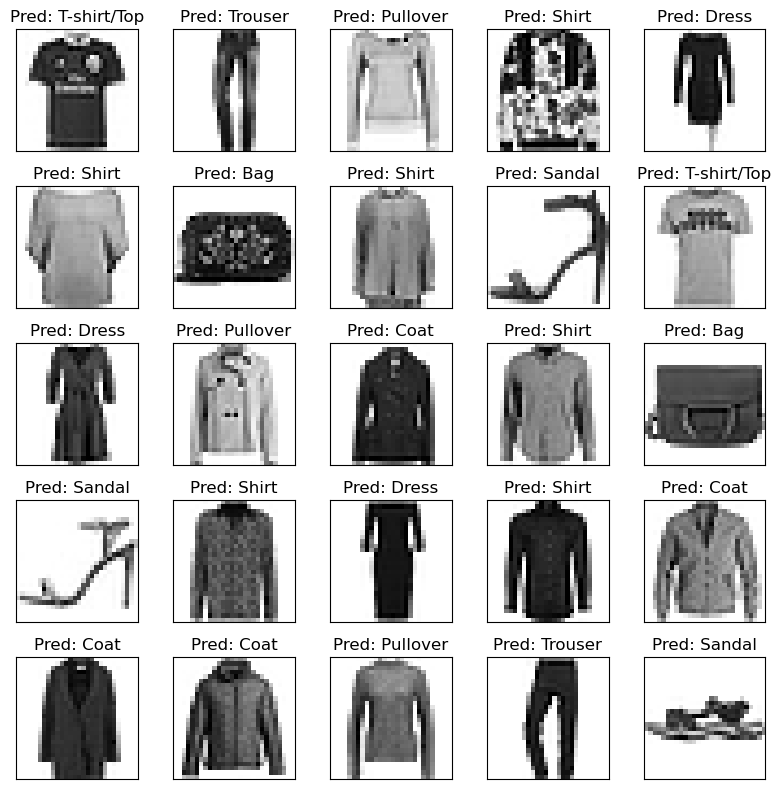

In [25]:
plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.xticks([]), plt.yticks([]), plt.grid(False)
    plt.imshow(x_test[i], cmap='binary')
    plt.title(f"Pred: {class_names[y_pred[i]]}")
plt.tight_layout()
plt.show()

In [26]:
print(classification_report(y_test, y_pred, target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/Top       0.89      0.80      0.84      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.94      0.71      0.81      1000
       Dress       0.94      0.90      0.92      1000
        Coat       0.81      0.90      0.85      1000
      Sandal       0.99      0.96      0.98      1000
       Shirt       0.65      0.83      0.73      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.99      0.98      0.99      1000
  Ancle boot       0.97      0.97      0.97      1000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.90     10000
weighted avg       0.91      0.90      0.90     10000



In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8998
